# Module 6 / Class 4 - CNN Regularization With Dropout

This notebook uses CIFAR-10 and completes the dropout-rate
experiment. It trains the no-dropout model, the mixed Dropout model,
a low-dropout model, and a high-dropout model.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from IPython.display import Markdown, display

np.random.seed(42)
tf.keras.utils.set_random_seed(42)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Load and Prepare CIFAR-10

CIFAR-10 has 32 by 32 color images from 10 classes. A CPU-friendly
subset is used so all required 10-epoch comparisons run locally in a
reasonable time.

In [2]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.cifar10.load_data()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

y_train_full = y_train_full.reshape(-1)
y_test_full = y_test_full.reshape(-1)

x_train = x_train_full[:2500].astype("float32") / 255.0
y_train = y_train_full[:2500]
x_valid = x_train_full[2500:3500].astype("float32") / 255.0
y_valid = y_train_full[2500:3500]
x_test = x_test_full[:1000].astype("float32") / 255.0
y_test = y_test_full[:1000]

print("train:", x_train.shape, "valid:", x_valid.shape, "test:", x_test.shape)

train: (2500, 32, 32, 3) valid: (1000, 32, 32, 3) test: (1000, 32, 32, 3)


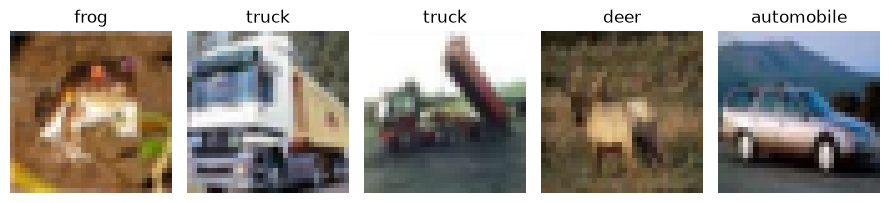

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(9, 2))
for ax, image, label in zip(axes, x_train[:5], y_train[:5]):
    ax.imshow(image)
    ax.set_title(class_names[label])
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Model Builders

The low and high models use Dropout after every main layer/block.
The mixed model uses `Dropout(0.25)` after each pooling layer and
`Dropout(0.5)` before the output layer.

In [4]:
EPOCHS = 10
BATCH_SIZE = 128

def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def build_no_dropout_model():
    return compile_model(keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]))

def build_mixed_dropout_model():
    return compile_model(keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax"),
    ]))

def build_everywhere_dropout_model(rate):
    return compile_model(keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
        layers.Dropout(rate),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(rate),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.Dropout(rate),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(rate),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(rate),
        layers.Dense(10, activation="softmax"),
    ]))

## 3. Train Dropout Configurations for 10 Epochs

The required experiments are low Dropout `0.1` and high Dropout
`0.5`. I also include the no-dropout and mixed `0.25 / 0.5` models
for comparison.

In [5]:
model_factories = {
    "no dropout": build_no_dropout_model,
    "mixed 0.25 / 0.5": build_mixed_dropout_model,
    "low 0.1 everywhere": lambda: build_everywhere_dropout_model(0.1),
    "high 0.5 everywhere": lambda: build_everywhere_dropout_model(0.5),
}

histories = {}
summary_rows = []

for model_name, build_model in model_factories.items():
    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    model = build_model()
    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_valid, y_valid),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]
    histories[model_name] = history.history
    summary_rows.append({
        "dropout_configuration": model_name,
        "final_train_accuracy": train_acc,
        "final_validation_accuracy": val_acc,
        "overfitting_gap": train_acc - val_acc,
        "test_accuracy": test_accuracy,
    })

dropout_results = pd.DataFrame(summary_rows).sort_values("final_validation_accuracy", ascending=False)
dropout_results

,dropout_configuration,final_train_accuracy,final_validation_accuracy,overfitting_gap,test_accuracy
2,low 0.1 everywhere,0.5124,0.459,0.0534,0.430
0,no dropout,0.5240,0.428,0.0960,0.432
1,mixed 0.25 / 0.5,0.3596,0.399,-0.0394,0.401
3,high 0.5 everywhere,0.3000,0.333,-0.0330,0.335


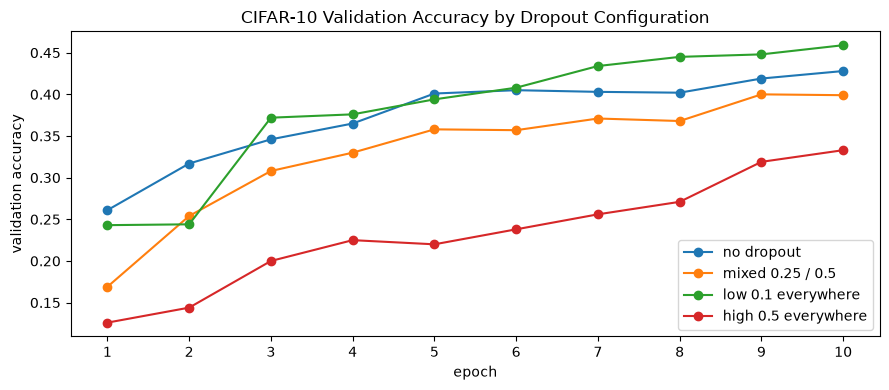

In [6]:
plt.figure(figsize=(9, 4))
for model_name, history in histories.items():
    plt.plot(history["val_accuracy"], marker="o", label=model_name)

plt.title("CIFAR-10 Validation Accuracy by Dropout Configuration")
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.xticks(range(EPOCHS), [str(i) for i in range(1, EPOCHS + 1)])
plt.legend()
plt.tight_layout()
plt.show()

## 4. Dropout Experiment Report - Completed

The next cell reports final validation accuracy, overfitting gap,
and the best dropout configuration from this run.

In [7]:
best_row = dropout_results.iloc[0]
low_gap = dropout_results.loc[
    dropout_results["dropout_configuration"] == "low 0.1 everywhere",
    "overfitting_gap",
].iloc[0]
high_gap = dropout_results.loc[
    dropout_results["dropout_configuration"] == "high 0.5 everywhere",
    "overfitting_gap",
].iloc[0]

answer = f'''
- **Best validation accuracy:** `{best_row["dropout_configuration"]}` with `{best_row["final_validation_accuracy"]:.4f}`.
- **Low dropout gap:** `{low_gap:.4f}`.
- **High dropout gap:** `{high_gap:.4f}`.
- **Which worked best?** The best configuration in this run is `{best_row["dropout_configuration"]}`. Low dropout usually keeps more learning capacity, while high dropout can regularize strongly but may slow learning.
'''

display(Markdown(answer))


- **Best validation accuracy:** `low 0.1 everywhere` with `0.4590`.
- **Low dropout gap:** `0.0534`.
- **High dropout gap:** `-0.0330`.
- **Which worked best?** The best configuration in this run is `low 0.1 everywhere`. Low dropout usually keeps more learning capacity, while high dropout can regularize strongly but may slow learning.
